# Evaluation (Pandas)

## R2
The Coefficient of Determination, R2, is a measure of how well the model fits the data. 
It is a value between 0 and 1. It tells us how much of the variance in the target variable 
is predictable from the features. 
    
A value of 0 means that the model explains none of the variability. 
A value of 1 means that the model explains all the variability. 
    
Note that it doesn't indicate whether a model is overfitting or underfitting the data.

In [1]:
from sklearn.model_selection import train_test_split
# Custom import
from get_dataset_pandas import get_pandas_df
from pipes_and_transformers_pandas import get_pipeline_pandas

# Gets Pandas dataframe.
raw = get_pandas_df()

y = raw["price"]
X_train, X_test, y_train, y_test = train_test_split(raw, y, test_size=0.2, random_state=42)

In [2]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor()
cat_pipe = get_pipeline_pandas(cat)
cat_pipe.fit(X_train, y_train)

print(cat_pipe.score(X_test, y_test))

Learning rate set to 0.064232
0:	learn: 346982.2594620	total: 139ms	remaining: 2m 18s
1:	learn: 332378.5598059	total: 142ms	remaining: 1m 10s
2:	learn: 319502.6617458	total: 145ms	remaining: 48.2s
3:	learn: 307490.7902475	total: 148ms	remaining: 36.8s
4:	learn: 294940.3225791	total: 150ms	remaining: 29.9s
5:	learn: 283907.9796375	total: 154ms	remaining: 25.5s
6:	learn: 273592.5548762	total: 157ms	remaining: 22.3s
7:	learn: 263472.9134855	total: 160ms	remaining: 19.9s
8:	learn: 254884.3331936	total: 163ms	remaining: 17.9s
9:	learn: 246261.9209853	total: 167ms	remaining: 16.5s
10:	learn: 238183.5765242	total: 171ms	remaining: 15.4s
11:	learn: 230600.1564374	total: 175ms	remaining: 14.4s
12:	learn: 223779.4367347	total: 179ms	remaining: 13.6s
13:	learn: 217021.8170437	total: 186ms	remaining: 13.1s
14:	learn: 210875.7711670	total: 192ms	remaining: 12.6s
15:	learn: 205122.1910805	total: 206ms	remaining: 12.6s
16:	learn: 199643.2642325	total: 213ms	remaining: 12.3s
17:	learn: 194468.6623792	

## Mean Squared/ Absolute Error

In [3]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, cat_pipe.predict(X_test))

14415098613.389244

In [4]:
# rmse
# Unable to get this to work.
# mean_squared_error(y_test, cat_pipe.predict(X_test), squared=False)

# Alternative
import numpy as np

mse = mean_squared_error(y_test, cat_pipe.predict(X_test))
rmse = np.sqrt(mse)
print(rmse)

120062.89440701171


In [5]:
# absolute error
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, cat_pipe.predict(X_test))

64449.15608948771

## Compare lr model

In [6]:
from sklearn.linear_model import LinearRegression

lr =  LinearRegression()
lr_pipe = get_pipeline_pandas(lr)
lr_pipe.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, lr_pipe.predict(X_test))

98969.57211943857

## Residual Plot

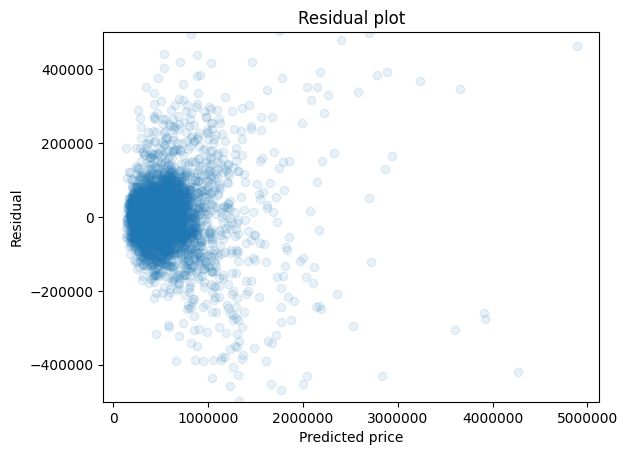

In [7]:
# make a residual plot
import matplotlib.pyplot as plt

ax = plt.scatter(cat_pipe.predict(X_test), 
    y_test - cat_pipe.predict(X_test), alpha=0.1)
# make labels not be scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.ylim(-500_000, 500_000)
plt.xlabel('Predicted price')
plt.ylabel('Residual')
plt.title('Residual plot')
plt.show()

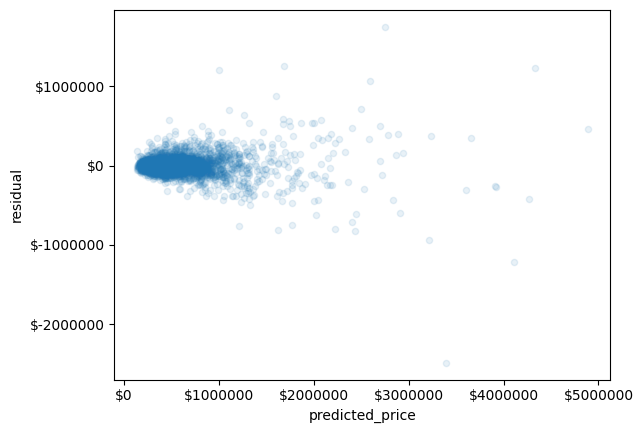

In [8]:
import pandas as pd

df = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": cat_pipe.predict(X_test)
})
df["residual"] = df["actual_price"] - df["predicted_price"]

# Scatter plot
ax = df.plot.scatter(
    x="predicted_price",
    y="residual",
    alpha=0.1
)

# Format axes with currency style
ax.xaxis.set_major_formatter('${:.0f}'.format)
ax.yaxis.set_major_formatter('${:.0f}'.format)

plt.show()

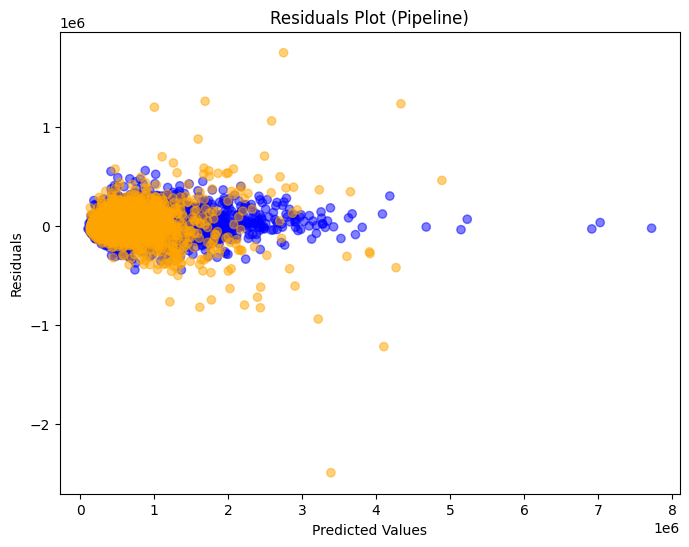

In [9]:
# Function to plot residual plot
def residuals_plot(model, X_train, y_train, X_test, y_test):
    # Predictions from the pipeline
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Build DataFrames for train and test residuals
    df_train = pd.DataFrame({
        "prediction": y_train_pred,
        "residual": y_train - y_train_pred,
        "type": "train"
    })

    df_test = pd.DataFrame({
        "prediction": y_test_pred,
        "residual": y_test - y_test_pred,
        "type": "test"
    })

    # Combine train and test residuals
    df = pd.concat([df_train, df_test], ignore_index=True)

    # Plot residuals
    plt.figure(figsize=(8, 6))
    colors = df["type"].map({"train": "blue", "test": "orange"})
    plt.scatter(df["prediction"], df["residual"], alpha=0.5, c=colors)
##    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals Plot (Pipeline)")
##    plt.legend(["Zero line", "Train", "Test"])
    plt.show()

residuals_plot(cat_pipe, X_train, y_train, X_test, y_test)

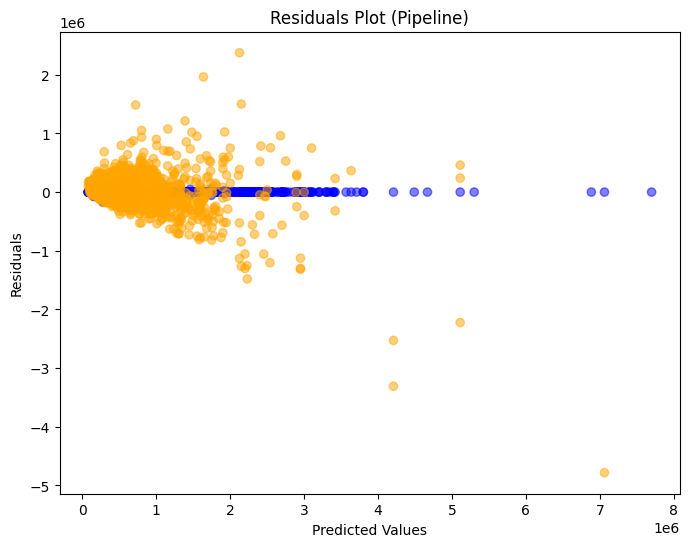

In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt_pipe = get_pipeline_pandas(dt)
dt_pipe.fit(X_train, y_train)

residuals_plot(dt_pipe, X_train, y_train, X_test, y_test)